                                                                                            by Maria 

# <center> CNN using Pytorch

# Задание 1 - LeNet-5 with Pytorch

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import torch
import torchvision
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from skimage.feature import hog
import time
import torch.nn.functional as F

Во многих западных странах информация на почтовых конвертах, в том числе и почтовый индекс,
заполняются прописью от руки. Это затрудняет сортировку корреспонденции в почтовых
отделениях. Для автоматизации процесса учёным Яном Лекуном (Yann LeCun) была предложена
первая в истории нейронная сеть – LeNet. А для тренировки данной нейронной сети был создан
уже известный датасет MNIST.

В данной задаче вам предстоит воспроизвести модификацию нейронной сети LeNet-5. Фактически
часть этой нейронной сети у вас уже готова – ваш многослойный перцептрон, написанный ранее,
представляет собой ряд Fully Connected слоёв в выходной части нейронной сети. Вам необходимо
воспроизвести следующие слои в нейронной сети:

    · Convolution
    · Pooling (Average Pooling)
    · Activation (ReLU)

Для воспроизведения последовательности слоев и их внутренних параметров, ориентируемся на
следующую статью: https://medium.com/@siddheshb008/lenet-5-architecture-explained-3b559cb2d52b
Для написания и тренировки всей архитектуры используйте pytorch.

### Общая структура LeNet-5

LeNet-5 представляет собой небольшую сверточную нейронную сеть, которая является основой многих современных моделей глубокого обучения. Она включает три ключевых элемента: сверточные слои, слои субдискретизации (пулинга) и полносвязные слои. Эта архитектура была разработана для распознавания рукописных символов, но ее идеи широко применяются в других задачах компьютерного зрения. Она является основой для других моделей глубокого обучения. 

LeNet-5 состоит из семи уровней (без учета входного слоя), в каждом из которых имеются обучаемые параметры. Каждый слой включает несколько карт признаков (feature maps), которые получаются в результате свертки и объединения. В результате каждая карта содержит информацию о локальных признаках изображения.

![img](./data/img/medlenet.webp)

### Входной слой
- **Входные данные**: изображение размером `32x32` (нормализованное).  
- **Примечание**: Входной слой традиционно не считается частью архитектуры.

---

### Слой C1 (Слой свертки)
- **Входное изображение**: `32x32`
- **Размер ядра свертки**: `5x5`
- **Количество фильтров**: 6
- **Размер карты признаков на выходе**: `28x28` (расчет: `32 - 5 + 1 = 28`)
- **Количество нейронов**: `28x28x6 = 4704`
- **Обучаемые параметры**: `(5x5 + 1) x 6 = 156`
- **Количество связей**: `(5x5 + 1) x 6 x 28x28 = 122304`
- **Функция активации**: `Tanh` 

---

### Слой S2 (Слой пулинга)
- **Вход**: `28x28`
- **Размер области пулинга**: `2x2`
- **Тип пулинга**: `average`
- **Количество карт признаков**: 6
- **Размер карты признаков на выходе**: `14x14` (расчет: `28 / 2 = 14`)
- **Количество нейронов**: `14x14x6 = 1176`
- **Обучаемые параметры**: `2x6 = 12`
- **Количество связей**: `(2x2 + 1) x 6 x 14x14 = 5880`

---

### Слой C3 (Слой свертки)
- **Вход**: карты признаков из S2 (разные комбинации)
- **Размер ядра свертки**: `5x5`
- **Количество фильтров**: 16
- **Размер карты признаков на выходе**: `10x10` (расчет: `14 - 5 + 1 = 10`)
- **Количество обучаемых параметров**: 1516
- **Количество связей**: `10x10x1516 = 151600`
- **Функция активации**: `Tanh` 

---

### Слой S4 (Слой пулинга)
- **Вход**: `10x10`
- **Размер области пулинга**: `2x2`
- **Тип пулинга**: `average`
- **Количество карт признаков**: 16
- **Размер карты признаков на выходе**: `5x5` (расчет: `10 / 2 = 5`)
- **Количество нейронов**: `5x5x16 = 400`
- **Обучаемые параметры**: `2x16 = 32`
- **Количество связей**: `16 x (2x2 + 1) x 5x5 = 2000`

---

### Слой C5 (Слой свертки)
- **Вход**: все карты признаков из S4
- **Размер ядра свертки**: `5x5`
- **Количество фильтров**: 120
- **Размер карты признаков на выходе**: `1x1` (расчет: `5 - 5 + 1 = 1`)
- **Количество обучаемых параметров**: `120x(16x5x5 + 1) = 48120`
- **Функция активации**: `Tanh` 

---

### Слой F6 (Полносвязный слой)
- **Вход**: вектор из C5 (`120x1`)
- **Количество нейронов**: 84
- **Обучаемые параметры**: `(120 + 1)x84 = 10164`
- **Функция активации**: `Tanh` 

---

### Выходной слой
- **Вход**: вектор из F6 (`84x1`)
- **Количество нейронов**: 10 (по числу классов)
- **Обучаемые параметры**: `84x10 = 840`
- **Функция активации**: `Softmax`

In [5]:
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

In [6]:
batch_size = 64 

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

Мы с командой пересчитали параметры для LeNet-5 со входом 28*28, а также решили выбрать ReLu в качетсве функции активации. 

Вот оторректированная схема слоев модели

![img](./data/img/my_lenet5_upd.png)

# Архитектура LeNet-5 (вход 28x28)

## 1. Входной слой
- **Размер входа**: `28x28`

---

## 2. Слой C1 (Свертка)
- **Количество фильтров**: 6  
- **Размер ядра**: `5x5`  
- **Размер выхода**: `24x24` (расчет: `28 - 5 + 1`)  
- **Обучаемые параметры**: `(5x5 + 1) x 6 = 156`
- **Функция активации**: `Relu` 

---

## 3. Слой S2 (Пулинг)
- **Тип пулинга**: `average` 
- **Размер окна**: `2x2`  
- **Размер выхода**: `12x12` (расчет: `24 / 2`)  
- **Обучаемые параметры**: `2x6 = 12` 

---

## 4. Слой C3 (Свертка)
- **Количество фильтров**: 16  
- **Размер ядра**: `5x5`  
- **Размер выхода**: `8x8` (расчет: `12 - 5 + 1`)  
- **Обучаемые параметры**: `(5x5x6 + 1) x 16 = 2416`
- **Функция активации**: `Relu`

---

## 5. Слой S4 (Пулинг)
- **Тип пулинга**: `average`  
- **Размер окна**: `2x2`  
- **Размер выхода**: `4x4` (расчет: `8 / 2`)  
- **Обучаемые параметры**: `2x16 = 32`

---

## 6. Слой C5 (Свертка)
- **Количество фильтров**: 120  
- **Размер ядра**: `4x4`  
- **Размер выхода**: `1x1`  
- **Обучаемые параметры**: `(4x4x16 + 1) x 120 = 30840`
- **Функция активации**: `Relu`

---

## 7. Слой F6 (Полносвязный)
- **Вход**: вектор из 120 элементов  
- **Выход**: 84 нейрона  
- **Обучаемые параметры**: `(120 + 1) x 84 = 10164`
- **Функция активации**: `Relu`
---

## 8. Выходной слой
- **Вход**: 84 нейрона  
- **Выход**: 10 классов  
- **Обучаемые параметры**: `(84 + 1) x 10 = 850`
- **Функция активации**: `Softmax`

In [29]:
class LeNet5(nn.Module):
    def __init__(self, num_classes=10):
        super(LeNet5, self).__init__()

        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, stride=1, padding=0)

        self.pool1 = nn.AvgPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, stride=1, padding=0)

        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)

        # Вход: 16 каналов, выход: 120 каналов, размер ядра 4x4 (как размер карт активации после предыдущей свертки), шаг 1
        self.conv3 = nn.Conv2d(16, 120, kernel_size=4, stride=1, padding=0)

        self.fc1 = nn.Linear(120, 84)  # Из 120 в 84
        
        self.fc2 = nn.Linear(84, num_classes)  # Из 84 в num_classes (по умолчанию 10)

    def forward(self, x):
        x = self.conv1(x)  
        x = torch.relu(x)  
        x = self.pool1(x)  
        x = self.conv2(x) 
        x = torch.relu(x)  
        x = self.pool2(x)  
        x = self.conv3(x)  
        x = torch.relu(x)  
   
        x = x.view(-1, 120)  

        x = torch.relu(self.fc1(x))  # Линейный слой + активация
        x = self.fc2(x)
        
#здесь попробовала с tanh в кач-ве функции активации
#         x = self.conv1(x)  
#         x = torch.tanh(x)  
#         x = self.pool1(x)  
#         x = self.conv2(x) 
#         x = torch.tanh(x)  
#         x = self.pool2(x)  
#         x = self.conv3(x)  
#         x = torch.tanh(x)  

#         x = x.view(-1, 120)  

#         x = torch.tanh(self.fc1(x))  # Линейный слой + активация
#         x = self.fc2(x)

        return x

    def fit(self, train_loader, val_loader, num_epochs, learning_rate):

        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(self.parameters(), lr=learning_rate)

        train_losses = []
        val_losses = []

        start_time = time.time()  
        for epoch in range(num_epochs):
            self.train() 
            epoch_loss = 0.0
            for images, labels in train_loader:
                optimizer.zero_grad()  
                outputs = self(images) 
                loss = criterion(outputs, labels)  
                loss.backward()
                optimizer.step() 
                epoch_loss += loss.item()

            avg_epoch_loss = epoch_loss / len(train_loader)
            train_losses.append(avg_epoch_loss)
            print(f'Epoch [{epoch + 1}/{num_epochs}], Training Loss: {avg_epoch_loss:.4f}')

            self.eval()  
            val_epoch_loss = 0.0
            with torch.no_grad(): 
                for images, labels in val_loader:
                    outputs = self(images) 
                    loss = criterion(outputs, labels)
                    val_epoch_loss += loss.item()

            avg_val_loss = val_epoch_loss / len(val_loader)
            val_losses.append(avg_val_loss)
            print(f'Epoch [{epoch + 1}/{num_epochs}], Validation Loss: {avg_val_loss:.4f}\n')

        total_time = time.time() - start_time
        print(f'Total fitting time: {total_time:.2f} seconds')

        self.plot_losses(train_losses, val_losses)

        return train_losses, val_losses

    def evaluate(self, test_loader):

        self.eval()  
        all_labels = [] 
        all_predictions = [] 

        with torch.no_grad():  
            for images, labels in test_loader:
                outputs = self(images) 
                _, predicted = torch.max(outputs.data, 1) 
                all_labels.extend(labels.numpy())  
                all_predictions.extend(predicted.numpy())  

        accuracy = sum(np.array(all_predictions) == np.array(all_labels)) / len(all_labels)
        print(f'Accuracy: {accuracy * 100:.2f}%')

        report = classification_report(all_labels, all_predictions, digits=4)
        print(report)

        cm = confusion_matrix(all_labels, all_predictions)
        self.confusion_matrix_visualisation(cm)

    def plot_losses(self, train_losses, val_losses):

        plt.figure(figsize=(10, 5))
        plt.plot(train_losses, label='Training Loss', color='blue')
        plt.plot(val_losses, label='Validation Loss', color='orange')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.title('Training and Validation Losses')
        plt.legend()
        plt.grid()
        plt.show()

    def confusion_matrix_visualisation(self, cm):

        plt.figure(figsize=(8, 5))
        sns.heatmap(cm, square=True, annot=True, cmap='BuPu')
        plt.title('Confusion Matrix')
        plt.ylabel('Actual Class')
        plt.xlabel('Predicted Class')
        plt.tight_layout()
        plt.show()

In [68]:
model = LeNet5(num_classes=10)

Epoch [1/8], Training Loss: 0.4104
Epoch [1/8], Validation Loss: 0.1388

Epoch [2/8], Training Loss: 0.1035
Epoch [2/8], Validation Loss: 0.0705

Epoch [3/8], Training Loss: 0.0686
Epoch [3/8], Validation Loss: 0.0583

Epoch [4/8], Training Loss: 0.0557
Epoch [4/8], Validation Loss: 0.0448

Epoch [5/8], Training Loss: 0.0451
Epoch [5/8], Validation Loss: 0.0379

Epoch [6/8], Training Loss: 0.0382
Epoch [6/8], Validation Loss: 0.0339

Epoch [7/8], Training Loss: 0.0333
Epoch [7/8], Validation Loss: 0.0392

Epoch [8/8], Training Loss: 0.0293
Epoch [8/8], Validation Loss: 0.0306

Total fitting time: 139.10 seconds


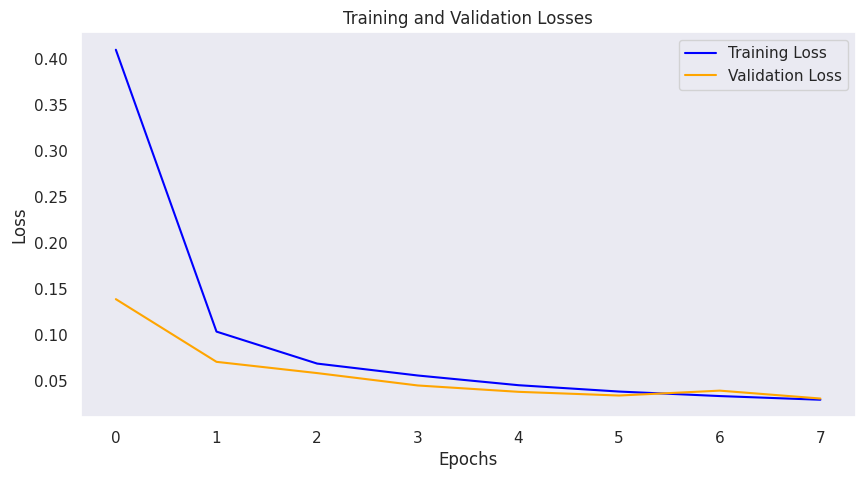

Total fitting time: 139.32 seconds


In [69]:
num_epochs = 8
learning_rate = 0.0006

start_time = time.time()
train_losses, val_losses = model.fit(train_loader, test_loader, num_epochs, learning_rate)
total_time = time.time() - start_time
print(f'Total fitting time: {total_time:.2f} seconds')

Accuracy: 99.02%
              precision    recall  f1-score   support

           0     0.9909    0.9969    0.9939       980
           1     0.9947    0.9982    0.9965      1135
           2     0.9951    0.9845    0.9898      1032
           3     0.9815    0.9960    0.9887      1010
           4     0.9898    0.9919    0.9908       982
           5     0.9822    0.9888    0.9855       892
           6     0.9916    0.9854    0.9885       958
           7     0.9884    0.9912    0.9898      1028
           8     0.9958    0.9836    0.9897       974
           9     0.9910    0.9841    0.9876      1009

    accuracy                         0.9902     10000
   macro avg     0.9901    0.9901    0.9901     10000
weighted avg     0.9902    0.9902    0.9902     10000



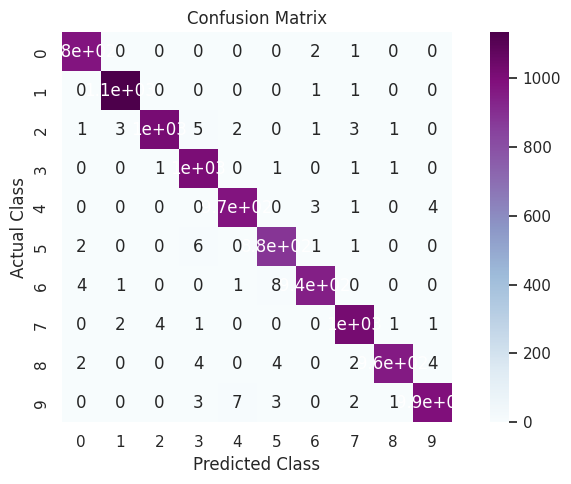

In [70]:
model.evaluate(test_loader)

Видим, что наша LiNet-5 отлично справляется с классификацией MNIST 28*28